**The Project's Core Goal — Risk Scoring**

Q11 — Can you build a composite risk score that identifies hospitals most likely to harm patients or waste Medicare resources?
Definition: composite risk score = a single calculated number combining multiple quality signals — readmission ratios, mortality rates, PSI scores, spending, and HAI rates — weighted by their importance.

This is the final deliverable. Not "which hospital is bad at one thing" but "which hospitals are consistently underperforming across multiple dimensions simultaneously." That's the Hospital Quality & Readmission Risk Analyzer.


A composit risk score is when all dimensions gather into 1 score. As defined it has to be Quallity signals (MORT , PSI , HAI) and spending, waited by their importance which is something that must be investigated and defined before usage.

Besed on CMS overall-hospital-quality-star-rating **ON : https://data.cms.gov/provider-data/topics/hospitals/overall-hospital-quality-star-rating/**

The weights for the 2024 and 2025 Star Ratings are explicitly defined in official CMS technical documents as follows:
1. Mortality (MORT): 22%
2. Safety of Care (PSI & HAI): 22%
3. Readmission: 22%
4. Patient Experience: 22%
5. Timely & Effective Care: 12% 

Spending (Efficiency): While Medicare Spending per Beneficiary is part of the Hospital Value-Based Purchasing (VBP) program (where it is weighted at **25%**), it is typically not included in the calculation for the 1-5 Star Ratings.

**Weight Redistribution:** 

If a hospital does not have enough data for a specific group (e.g., they don't report Patient Experience), CMS redistributes that group's weight proportionally among the remaining categories. For instance, if a group with a 22% weight is missing, that weight is split to increase the importance of the other outcome groups like Mortality and Safety.

Since adding spending to the list is mathematically > 100 

* Clinical Outcomes	MORT (Mortality measures)	25%
* Safety of Care	PSI-90 & HAI (Infections)	25%
* Efficiency & Cost	Spending (MSPB)         	25%
* Person & Community Engagement	Patient Experience (HCAHPS)	25%


*LET US GIVE IT A GO*

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np

In [10]:
general_info = pd.read_csv('general_info_cleaned.csv')
patient_experience = pd.read_csv('hcahps_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')
infections = pd.read_csv('associated_infections_cleaned.csv')
spending = pd.read_csv('medicare_cleaned.csv')


In [11]:
# Clinical Outcomes MORT (Mortality measures) 25% ______________________
##print(complications.filter(like = 'comp_score_mort'))

mortality_cols = [
    'comp_score_mort_30_ami', 'comp_score_mort_30_cabg',
    'comp_score_mort_30_copd', 'comp_score_mort_30_hf',
    'comp_score_mort_30_pn', 'comp_score_mort_30_stk'
]

for col in mortality_cols:
    complications[col] = pd.to_numeric(complications[col], errors='coerce')

complications['avg_mort_rate'] = complications[mortality_cols].mean(axis=1)


max_mort = complications['avg_mort_rate'].max()
min_mort = complications['avg_mort_rate'].min()

complications['clinical_quality_score'] = 100 * (1 - (complications['avg_mort_rate'] - min_mort) / (max_mort - min_mort))

complications['clinical_contribution'] = complications['clinical_quality_score'] * 0.25 

In [13]:
# Safety of Care PSI-90 & HAI (Infections) 25% ____________________________
safety_measures_hai = [
    'infection_score_hai_1_sir', 'infection_score_hai_2_sir', 
    'infection_score_hai_3_sir', 'infection_score_hai_4_sir', 
    'infection_score_hai_5_sir', 'infection_score_hai_6_sir'
]

for col in safety_measures_hai:
    infections[col] = pd.to_numeric(infections[col], errors='coerce')
complications['comp_score_psi_90'] = pd.to_numeric(complications['comp_score_psi_90'], errors='coerce')

safety_df = pd.merge(
    infections[['facility_id'] + safety_measures_hai], 
    complications[['facility_id', 'comp_score_psi_90']], 
    on='facility_id', 
    how='inner'
)

all_safety_cols = safety_measures_hai + ['comp_score_psi_90']
safety_df['avg_safety_rate'] = safety_df[all_safety_cols].mean(axis=1)

min_s = safety_df['avg_safety_rate'].min()
max_s = safety_df['avg_safety_rate'].max()

safety_df['safety_quality_score'] = 100 * (1 - (safety_df['avg_safety_rate'] - min_s) / (max_s - min_s))

safety_df['safety_contribution'] = safety_df['safety_quality_score'] * 0.25

In [16]:
# Efficiency & Cost Spending (MSPB) 25% _____________________________
spending_col = 'med_complete_episode__total'

spending[spending_col] = pd.to_numeric(spending[spending_col], errors='coerce')

max_spend = spending[spending_col].max()
min_spend = spending[spending_col].min()

spending['spending_quality_score'] = 100 * (1 - (spending[spending_col] - min_spend) / (max_spend - min_spend))

spending['spending_contribution'] = spending['spending_quality_score'] * 0.25

In [18]:
# Person & Community Engagement Patient Experience (HCAHPS) 25% _____________________
exp_cols = [
    'hcahps_linear_h_clean_linear_score', 'hcahps_linear_h_comp_1_linear_score', 
    'hcahps_linear_h_comp_2_linear_score', 'hcahps_linear_h_comp_5_linear_score', 
    'hcahps_linear_h_comp_6_linear_score', 'hcahps_linear_h_hsp_rating_linear_score', 
    'hcahps_linear_h_quiet_linear_score', 'hcahps_linear_h_recmnd_linear_score'
]

for col in exp_cols:
    patient_experience[col] = pd.to_numeric(patient_experience[col], errors='coerce')

patient_experience['avg_exp_score'] = patient_experience[exp_cols].mean(axis=1)

min_e = patient_experience['avg_exp_score'].min()
max_e = patient_experience['avg_exp_score'].max()

patient_experience['exp_quality_score'] = 100 * ((patient_experience['avg_exp_score'] - min_e) / (max_e - min_e))

patient_experience['exp_contribution'] = patient_experience['exp_quality_score'] * 0.25

In [67]:
# Merge all 4 contributions into one table ________________________________________

complications['facility_id'] = complications['facility_id'].astype(str).str.zfill(6)
safety_df['facility_id'] = safety_df['facility_id'].astype(str).str.zfill(6)
spending['facility_id'] = spending['facility_id'].astype(str).str.zfill(6)
patient_experience['facility_id'] = patient_experience['facility_id'].astype(str).str.zfill(6)

analyzer_master = complications[['facility_id', 'clinical_quality_score', 'clinical_contribution']].merge(
    safety_df[['facility_id', 'safety_quality_score', 'safety_contribution']], on='facility_id', how='left'
).merge(
    spending[['facility_id', 'spending_quality_score', 'spending_contribution']], on='facility_id', how='left'
).merge(
    patient_experience[['facility_id', 'exp_quality_score', 'exp_contribution']], on='facility_id', how='left'
)

analyzer_master['final_score_100'] = analyzer_master[['clinical_contribution', 'safety_contribution', 'spending_contribution', 'exp_contribution']].sum(axis=1)

analyzer_master = analyzer_master.merge(general_info[['facility_id', 'facility_name', 'state']], on='facility_id', how='left')

diagnostic_view = analyzer_master[[
    'facility_name', 
    'clinical_quality_score', 
    'safety_quality_score', 
    'spending_quality_score', 
    'exp_quality_score', 
    'final_score_100'
]].sort_values('final_score_100', ascending=False).reset_index(drop=True)

diagnostic_view
diagnostic_view.to_csv('analyzer_diagnostic_view_all_dimensions.csv', index=False)
print("Saved")
diagnostic_view

Saved


,facility_name,clinical_quality_score,safety_quality_score,spending_quality_score,exp_quality_score,final_score_100
0,CAPE FEAR VALLEY HOKE HOSPITAL,74.529915,93.261649,83.054553,81.147541,82.998414
1,FAYETTE MEDICAL CENTER,68.376068,100.000000,74.893408,84.836066,82.026385
2,CITIZENS MEDICAL CENTER,67.350427,85.806452,77.533618,97.131148,81.955411
3,ST JOHNS MEDICAL CENTER,83.076923,91.397849,73.351919,79.918033,81.936181
4,BUCHANAN GENERAL HOSPITAL,71.282051,89.369176,79.080573,86.885246,81.654261
...,...,...,...,...,...,...
4179,ANTELOPE MEMORIAL HOSPITAL,NaN,NaN,NaN,NaN,0.000000
4180,BROWN COUNTY HOSPITAL,NaN,NaN,NaN,NaN,0.000000
4181,MORRILL COUNTY COMMUNITY HOSPITAL,NaN,NaN,NaN,NaN,0.000000
4182,ANNIE JEFFREY MEMORIAL COUNTY HEALTH CENTER,NaN,NaN,NaN,NaN,0.000000


In [66]:
def categorize_hospital(row):
    hi_mort = row['clinical_quality_score'] >= 70
    hi_spend = row['spending_quality_score'] >= 70
    hi_psi = row['safety_quality_score'] >= 70
    hi_pe = row['exp_quality_score'] >= 70
    
    if hi_mort and hi_spend and hi_psi and hi_pe:
        return "The Elite All-Rounder"
    
    elif hi_mort and hi_psi and hi_spend:
        return "The Efficient Lifesaver"
    
    elif hi_mort and hi_pe and not hi_spend:
        return "The Premium Specialist"
    
    elif hi_spend and not hi_mort and not hi_psi:
        return "The Economy Option"
    
    elif hi_pe and not hi_mort and not hi_psi:
        return "The Hospitality Hospital"
    
    elif not hi_mort and not hi_psi and not hi_pe:
        return "Urgent Improvement Needed"
    
    else:
        return "Standard Mixed Performer"


analyzer_master['hospital_archetype'] = analyzer_master.apply(categorize_hospital, axis=1)

# Display the final results with the archetype next to the score
final_analyzer_table = analyzer_master[[ 'facility_id',
    'facility_name', 
    'clinical_quality_score', 
    'safety_quality_score', 
    'spending_quality_score', 
    'exp_quality_score', 
    'final_score_100','hospital_archetype'
]].sort_values('final_score_100', ascending=False).reset_index(drop=True)

final_analyzer_table

final_analyzer_table.to_csv('hospital_archetype_view_all_dimensions.csv', index=False)
print("Saved")
final_analyzer_table

Saved


,facility_id,facility_name,clinical_quality_score,safety_quality_score,spending_quality_score,exp_quality_score,final_score_100,hospital_archetype
0,340188,CAPE FEAR VALLEY HOKE HOSPITAL,74.529915,93.261649,83.054553,81.147541,82.998414,The Elite All-Rounder
1,010045,FAYETTE MEDICAL CENTER,68.376068,100.000000,74.893408,84.836066,82.026385,Standard Mixed Performer
2,190184,CITIZENS MEDICAL CENTER,67.350427,85.806452,77.533618,97.131148,81.955411,Standard Mixed Performer
3,530015,ST JOHNS MEDICAL CENTER,83.076923,91.397849,73.351919,79.918033,81.936181,The Elite All-Rounder
4,490127,BUCHANAN GENERAL HOSPITAL,71.282051,89.369176,79.080573,86.885246,81.654261,The Elite All-Rounder
...,...,...,...,...,...,...,...,...
4179,281326,ANTELOPE MEMORIAL HOSPITAL,NaN,NaN,NaN,NaN,0.000000,Urgent Improvement Needed
4180,281325,BROWN COUNTY HOSPITAL,NaN,NaN,NaN,NaN,0.000000,Urgent Improvement Needed
4181,281318,MORRILL COUNTY COMMUNITY HOSPITAL,NaN,NaN,NaN,NaN,0.000000,Urgent Improvement Needed
4182,281314,ANNIE JEFFREY MEMORIAL COUNTY HEALTH CENTER,NaN,NaN,NaN,NaN,0.000000,Urgent Improvement Needed


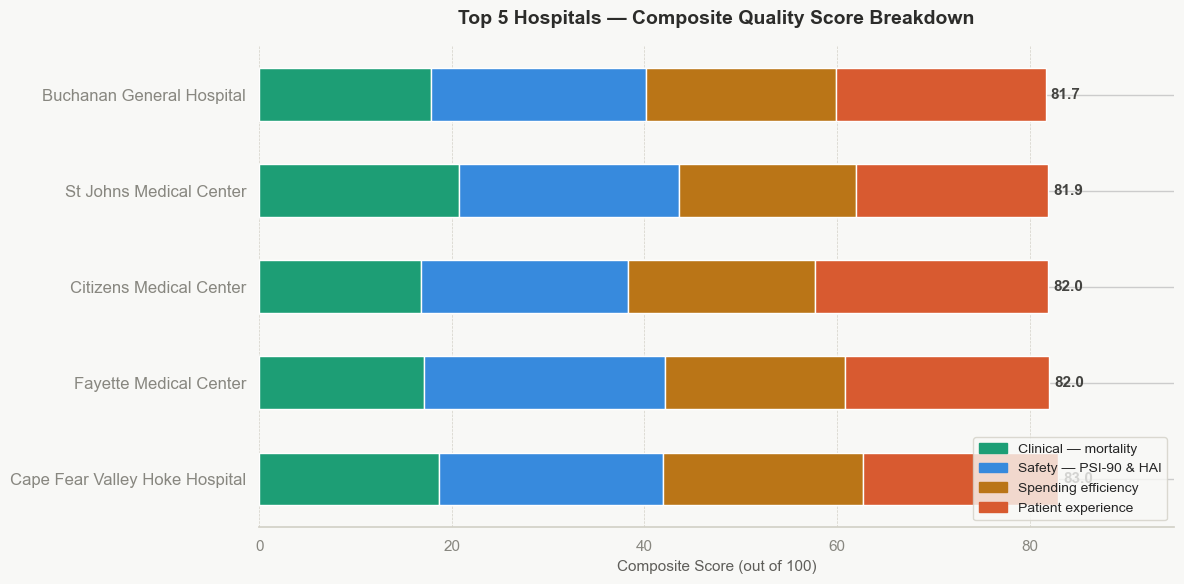

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('hospital_archetype_view_all_dimensions.csv')
df = df.dropna(subset=['clinical_quality_score','safety_quality_score','spending_quality_score','exp_quality_score'])
top5 = df.nlargest(5, 'final_score_100').reset_index(drop=True)

hospitals = [name.title() for name in top5['facility_name']]
clinical    = top5['clinical_quality_score'] * 0.25
safety      = top5['safety_quality_score']   * 0.25
spending    = top5['spending_quality_score']  * 0.25
experience  = top5['exp_quality_score']       * 0.25
totals      = top5['final_score_100']

colors = ['#1D9E75', '#378ADD', '#BA7517', '#D85A30']
labels = ['Clinical — mortality', 'Safety — PSI-90 & HAI', 'Spending efficiency', 'Patient experience']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8F8F6')
ax.set_facecolor('#F8F8F6')

y = np.arange(len(hospitals))
lefts = np.zeros(len(hospitals))

for i, (data, color, label) in enumerate(zip([clinical, safety, spending, experience], colors, labels)):
    bars = ax.barh(y, data, left=lefts, color=color, height=0.55, label=label)
    lefts += data.values

for i, (total, ypos) in enumerate(zip(totals, y)):
    ax.text(total + 0.5, ypos, f'{total:.1f}', va='center', ha='left',
            fontsize=11, fontweight='bold', color='#444441')

ax.set_yticks(y)
ax.set_yticklabels(hospitals, fontsize=12)
ax.set_xlabel('Composite Score (out of 100)', fontsize=11, color='#5F5E5A')
ax.set_xlim(0, 95)
ax.set_title('Top 5 Hospitals — Composite Quality Score Breakdown', fontsize=14, fontweight='bold', pad=16, color='#2C2C2A')
ax.tick_params(colors='#888780')
ax.spines[['top','right','left']].set_visible(False)
ax.spines['bottom'].set_edgecolor('#D3D1C7')
ax.xaxis.grid(True, color='#D3D1C7', linewidth=0.5, linestyle='--')
ax.set_axisbelow(True)

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax.legend(handles=patches, loc='lower right', fontsize=10, framealpha=0.8,
          edgecolor='#D3D1C7', facecolor='#F8F8F6')

plt.tight_layout()
plt.savefig('hospital_composite_score.png', dpi=150, bbox_inches='tight')
plt.show()

### AND WITH THAT THE PROJECT IS FULLY ANSWERED

### Check README for more.